In [1]:
!pip install pandas numpy matplotlib scikit-learn xgboost interpret shap seaborn openpyxl

Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import GroupShuffleSplit

print("Libraries imported successfully.")

Libraries imported successfully.


Loading the dataset

In [4]:
df = pd.read_csv("dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


 Inspecting the dataset

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Rows: 101766
Columns: 50

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


Target Variable

In [8]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [9]:
df["readmitted"].value_counts(normalize=True) * 100 #percentage value

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

In [10]:
df["target"] = (df["readmitted"] == "<30").astype(int) #creating the target

In [11]:
df["target"].value_counts()

target
0    90409
1    11357
Name: count, dtype: int64

In [12]:
df["target"].value_counts(normalize=True) * 100

target
0    88.840084
1    11.159916
Name: proportion, dtype: float64

Checking patients and repeated encounters

In [13]:
print("Total encounters:", len(df))
print("Unique patients:", df["patient_nbr"].nunique())

Total encounters: 101766
Unique patients: 71518


In [14]:
encounters_per_patient = df.groupby("patient_nbr").size()

print(encounters_per_patient.describe())

count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64


In [15]:
print(
    "Patients with more than one encounter:",
    (encounters_per_patient > 1).sum()
)

Patients with more than one encounter: 16773


Removeing identifiers

In [16]:
groups = df["patient_nbr"].copy()

In [17]:
df = df.drop(columns=["encounter_id", "patient_nbr"])

Handling missing values

In [18]:
missing_values = (df == "?").sum()

In [19]:
missing_values[missing_values > 0].sort_values(
    ascending=False
)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [20]:
df = df.replace("?", np.nan)

In [21]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,NO,0
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,Yes,NO,0
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


In [22]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

Defining the adult cohort

In [23]:
print(df["age"].value_counts().sort_index())

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


In [24]:
df = df[~df["age"].isin(["[0-10)", "[10-20)"])].copy()

In [25]:
print("Remaining records:", len(df))

Remaining records: 100914


In [26]:
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

target
0    89600
1    11314
Name: count, dtype: int64
target
0    88.788473
1    11.211527
Name: proportion, dtype: float64


In [27]:
print(df["race"].value_counts(dropna=False))
print(df["gender"].value_counts(dropna=False))
print(df["age"].value_counts(dropna=False).sort_index())

race
Caucasian          75525
AfricanAmerican    18985
NaN                 2263
Hispanic            2012
Other               1492
Asian                637
Name: count, dtype: int64
gender
Female             54223
Male               46688
Unknown/Invalid        3
Name: count, dtype: int64
age
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


Target visualisation

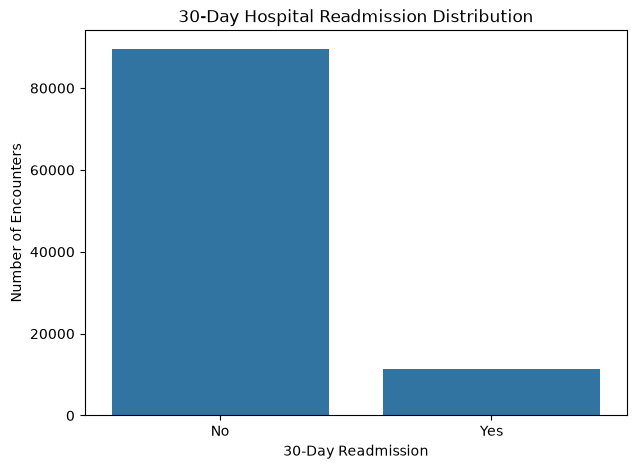

In [28]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="target"
)

plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("30-Day Readmission")
plt.ylabel("Number of Encounters")
plt.xticks([0, 1], ["No", "Yes"]) #changing label name

plt.show()

In [29]:
print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Dataset shape: (100914, 49)

Target distribution:
target
0    89600
1    11314
Name: count, dtype: int64

Missing values:
weight                      97740
max_glu_serum               95583
A1Cresult                   84339
medical_specialty           49693
payer_code                  39646
race                         2263
diag_3                       1106
diag_2                        222
diag_1                         21
time_in_hospital                0
admission_source_id             0
num_procedures                  0
num_lab_procedures              0
admission_type_id               0
discharge_disposition_id        0
age                             0
gender                          0
number_inpatient                0
number_emergency                0
number_outpatient               0
dtype: int64


In [30]:
X = df.drop(columns=["target"])

y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100914, 48)
y shape: (100914,)


In [31]:
groups = groups.loc[X.index].copy() #patient IDs correspond to the correct row

In [32]:
print("X:", len(X))
print("y:", len(y))
print("groups:", len(groups))

X: 100914
y: 100914
groups: 100914


In [33]:
#patient level splitting to remove the same patient appearing in both training and testing sets
from sklearn.model_selection import GroupShuffleSplit

#creating the splitter
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

In [34]:
print("Training records:", X_train.shape)
print("Testing records:", X_test.shape)

Training records: (80771, 48)
Testing records: (20143, 48)


In [35]:
overlap = set(groups_train).intersection(set(groups_test))

print("Patients appearing in both train and test:", len(overlap)) #checking for any overlapping patients

Patients appearing in both train and test: 0


In [36]:
df.head(2)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,Yes,NO,0
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,Up,No,No,No,No,No,Ch,Yes,NO,0


Finding categroical and numerical variables

In [37]:
df.dtypes

race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide                 str
glipizide                     str
glyburide     

In [38]:
categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nCategorical variables:")
print(categorical_features)

print("\nNumerical variables:")
print(numerical_features)


Categorical variables:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Numerical variables:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [39]:
X_train = X_train.drop(columns=["readmitted"])
X_test = X_test.drop(columns=["readmitted"])

In [40]:
print("readmitted" in X_train.columns)

False


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Training the Penalised Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [54]:
# Identify categorical and numerical features from the CURRENT X_train

categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical variables:")
print(categorical_features)

print("\nNumerical variables:")
print(numerical_features)

print("\nIs readmitted in X_train?",
      "readmitted" in X_train.columns)

print("\nIs readmitted in categorical_features?",
      "readmitted" in categorical_features)

Categorical variables:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Numerical variables:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Is readmitted in X_train? False

Is readmitted in categorical_features? False


In [56]:
logistic_model.fit(X_train, y_train)

print("Logistic regression training completed.")

Logistic regression training completed.


In [57]:
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [58]:
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

In [59]:
from sklearn.metrics import roc_auc_score
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.6445230822362589


In [60]:
from sklearn.metrics import average_precision_score
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

print("Logistic Regression PR-AUC:", pr_auc_lr)

Logistic Regression PR-AUC: 0.1907177114135445


In [61]:
y_test.mean() #test-set readmission prevalence

np.float64(0.11016233927418954)

In [62]:
from sklearn.metrics import confusion_matrix
def calculate_metrics(y_true, y_prob, threshold=0.5):
    
    y_pred = (y_prob >= threshold).astype(int)
    
    tn, fp, fn,  tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0 #of all patients who actually were readmitted (TPR)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 #of all patients who were not readmitted
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0 #how often the predicted readmission are actually correct
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0 #how often the predicted no readmission are actually correct
    
    return {
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv
    }

In [63]:
lr_metrics = calculate_metrics(
    y_test,
    y_prob_lr,
    threshold=0.5
)

lr_metrics

{'Sensitivity': np.float64(0.01216764308246958),
 'Specificity': np.float64(0.9981588931042178),
 'PPV': np.float64(0.45),
 'NPV': np.float64(0.8908529602151073)}

In [64]:
#barier Score
from sklearn.metrics import brier_score_loss
brier_lr = brier_score_loss(
    y_test,
    y_prob_lr
)

print("Logistic Regression Brier Score:", brier_lr)

Logistic Regression Brier Score: 0.09531464531676163


Calibration Curve

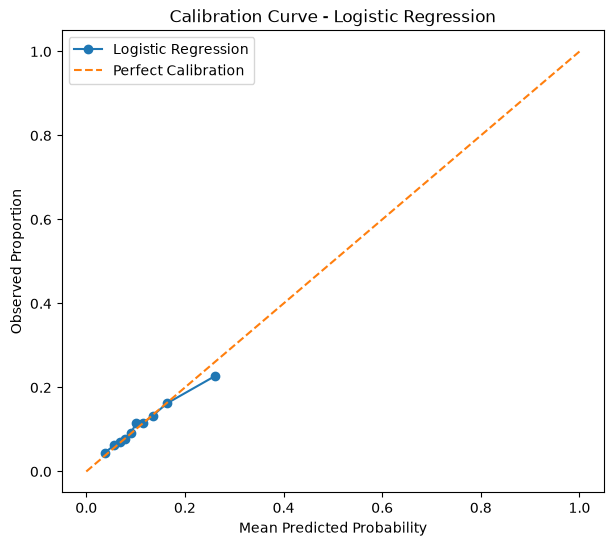

In [65]:
from sklearn.calibration import calibration_curve

prob_true_lr, prob_pred_lr = calibration_curve(
    y_test,
    y_prob_lr,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred_lr,
    prob_true_lr,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion")
plt.title("Calibration Curve - Logistic Regression")

plt.legend()
plt.show()

Cross-validation for Logistic Regression

In [66]:
#group validation for multiple encounters for the same patient
from sklearn.model_selection import StratifiedGroupKFold 

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [67]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

# Use the existing patient-level CV splits
cv_splits = list(
    cv.split(X_train, y_train, groups_train)
)

grid_lr = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv_splits,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print("Best parameters:", grid_lr.best_params_)
print("Best CV ROC-AUC:", grid_lr.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'model__C': 0.01}
Best CV ROC-AUC: 0.648438996889121


In [68]:
best_lr = grid_lr.best_estimator_

In [69]:
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

In [70]:
print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, y_prob_lr)
)

print(
    "Test PR-AUC:",
    average_precision_score(y_test, y_prob_lr)
)

print(
    "Brier Score:",
    brier_score_loss(y_test, y_prob_lr)
)

Test ROC-AUC: 0.6551237215184958
Test PR-AUC: 0.19660645252477432
Brier Score: 0.09488793666887062


EBM (Explainable Boosting Machine) model Training

In [71]:
X_train_ebm = X_train.copy()
X_test_ebm = X_test.copy()

In [72]:
#converting categorical variables into string
for col in categorical_features:
    X_train_ebm[col] = X_train_ebm[col].fillna("Unknown").astype(str)
    X_test_ebm[col] = X_test_ebm[col].fillna("Unknown").astype(str)

In [73]:
for col in numerical_features:
    median_value = X_train_ebm[col].median()
    
    X_train_ebm[col] = X_train_ebm[col].fillna(median_value)
    X_test_ebm[col] = X_test_ebm[col].fillna(median_value)

In [76]:
#training the model
from interpret.glassbox import ExplainableBoostingClassifier

ebm = ExplainableBoostingClassifier(
    interactions=10,
    max_bins=256,
    learning_rate=0.05,
    max_rounds=1000,
    random_state=42
)

ebm.fit(X_train_ebm, y_train)

print("EBM training completed.")

EBM training completed.


In [77]:
y_prob_ebm = ebm.predict_proba(X_test_ebm)[:, 1]

y_pred_ebm = (
    y_prob_ebm >= 0.5
).astype(int)

In [78]:
roc_auc_ebm = roc_auc_score(
    y_test,
    y_prob_ebm
)

pr_auc_ebm = average_precision_score(
    y_test,
    y_prob_ebm
)

brier_ebm = brier_score_loss(
    y_test,
    y_prob_ebm
)

print("EBM ROC-AUC:", roc_auc_ebm)
print("EBM PR-AUC:", pr_auc_ebm)
print("EBM Brier Score:", brier_ebm)

EBM ROC-AUC: 0.680552402970471
EBM PR-AUC: 0.21361481901503032
EBM Brier Score: 0.0936409628055948


In [79]:
ebm_global = ebm.explain_global()

ebm_global

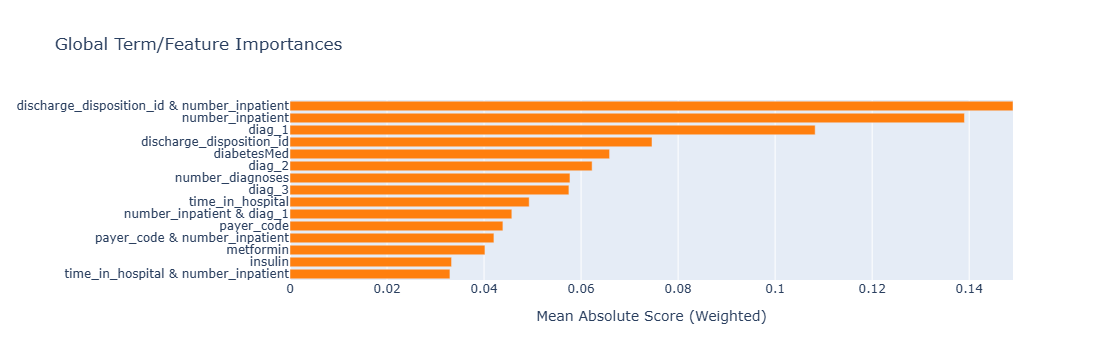

In [80]:
ebm_global.visualize()

XGBoost Training

In [81]:
xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features
        )
    ]
)

In [83]:
#class imbalance calculating
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 7.8808136338647605


In [85]:
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [86]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [87]:
#XGBoost probabilities
y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

In [88]:
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

pr_auc_xgb = average_precision_score(
    y_test,
    y_prob_xgb
)

brier_xgb = brier_score_loss(
    y_test,
    y_prob_xgb
)

print("XGBoost ROC-AUC:", roc_auc_xgb)
print("XGBoost PR-AUC:", pr_auc_xgb)
print("XGBoost Brier Score:", brier_xgb)

XGBoost ROC-AUC: 0.6782329230653806
XGBoost PR-AUC: 0.21765203134682287
XGBoost Brier Score: 0.2148016393184662


In [89]:
xgb_metrics = calculate_metrics(
    y_test,
    y_prob_xgb,
    threshold=0.5
)

xgb_metrics

{'Sensitivity': np.float64(0.5917079765660207),
 'Specificity': np.float64(0.6673175630439634),
 'PPV': np.float64(0.18045629466739968),
 'NPV': np.float64(0.9295873163907671)}

In [91]:
#comparing models
results = pd.DataFrame({
    "Model": [
        "Penalised Logistic Regression",
        "Explainable Boosting Machine",
        "XGBoost"
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_ebm),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    
    "PR-AUC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_ebm),
        average_precision_score(y_test, y_prob_xgb)
    ],
    
    "Brier Score": [
        brier_score_loss(y_test, y_prob_lr),
        brier_score_loss(y_test, y_prob_ebm),
        brier_score_loss(y_test, y_prob_xgb)
    ]
})

results

,Model,ROC-AUC,PR-AUC,Brier Score
0,Penalised Logistic Regression,0.655124,0.196606,0.094888
1,Explainable Boosting Machine,0.680552,0.213615,0.093641
2,XGBoost,0.678233,0.217652,0.214802


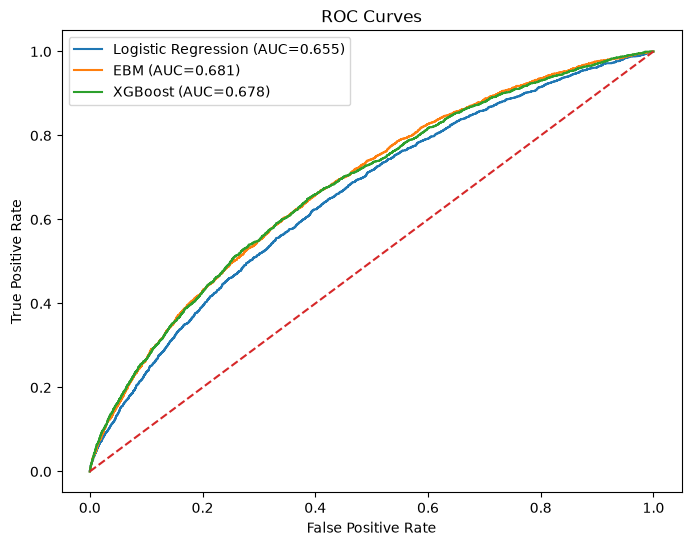

In [93]:
#comparing ROC curves
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_ebm, tpr_ebm, _ = roc_curve(y_test, y_prob_ebm)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})"
)

plt.plot(
    fpr_ebm,
    tpr_ebm,
    label=f"EBM (AUC={roc_auc_score(y_test, y_prob_ebm):.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

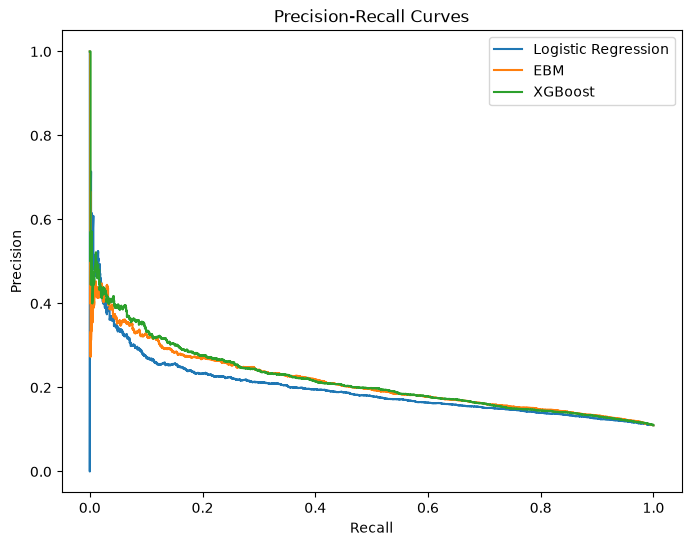

In [95]:
#compare Precision-Recall curves
from sklearn.metrics import precision_recall_curve

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    y_prob_lr
)

precision_ebm, recall_ebm, _ = precision_recall_curve(
    y_test,
    y_prob_ebm
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label="Logistic Regression"
)

plt.plot(
    recall_ebm,
    precision_ebm,
    label="EBM"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")

plt.legend()
plt.show()

In [97]:
#checking with different thresholds

thresholds = np.arange(
    0.05,
    0.96,
    0.05
)

threshold_results = []

for threshold in thresholds:
    
    metrics = calculate_metrics(
        y_test,
        y_prob_xgb,
        threshold=threshold
    )
    
    threshold_results.append({
        "Threshold": threshold,
        **metrics
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Sensitivity,Specificity,PPV,NPV
0,0.05,1.000000,0.000000,0.110162,0.000000
1,0.10,1.000000,0.002957,0.110453,1.000000
2,0.15,0.998197,0.015510,0.111525,0.985816
3,0.20,0.993240,0.034256,0.112945,0.976153
4,0.25,0.983326,0.070520,0.115805,0.971560
5,0.30,0.953583,0.145726,0.121414,0.962063
6,0.35,0.900856,0.265287,0.131791,0.955779
7,0.40,0.811627,0.404932,0.144461,0.945545
8,0.45,0.704822,0.542513,0.160180,0.936892
9,0.50,0.591708,0.667318,0.180456,0.929587


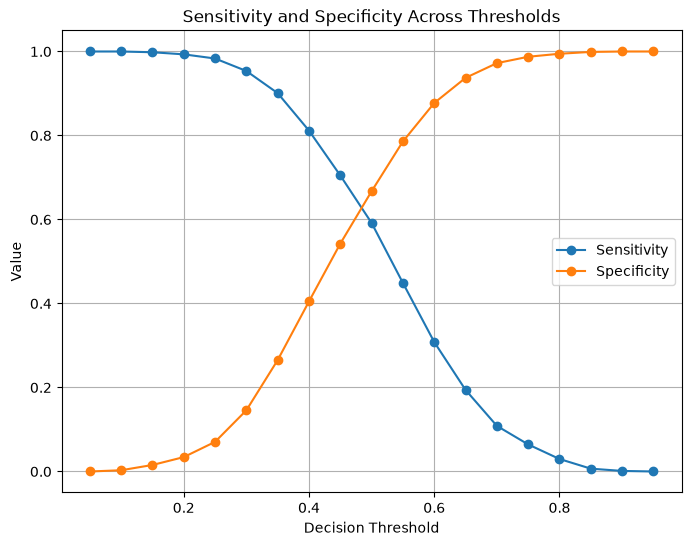

In [99]:
#plot sensitivity and specificity
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Sensitivity"],
    marker="o",
    label="Sensitivity"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Specificity"],
    marker="o",
    label="Specificity"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Value")
plt.title("Sensitivity and Specificity Across Thresholds")
plt.legend()
plt.grid()

plt.show()

In [101]:
#calibration curves for all models
from sklearn.calibration import calibration_curve

prob_true_lr, prob_pred_lr = calibration_curve(
    y_test,
    y_prob_lr,
    n_bins=10,
    strategy="quantile"
)

prob_true_ebm, prob_pred_ebm = calibration_curve(
    y_test,
    y_prob_ebm,
    n_bins=10,
    strategy="quantile"
)

prob_true_xgb, prob_pred_xgb = calibration_curve(
    y_test,
    y_prob_xgb,
    n_bins=10,
    strategy="quantile"
)

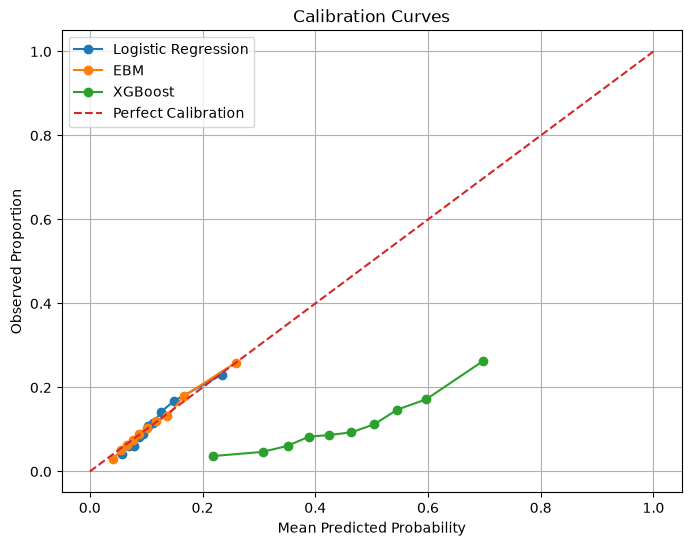

In [102]:
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_lr,
    prob_true_lr,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    prob_pred_ebm,
    prob_true_ebm,
    marker="o",
    label="EBM"
)

plt.plot(
    prob_pred_xgb,
    prob_true_xgb,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion")
plt.title("Calibration Curves")
plt.legend()
plt.grid()

plt.show()

In [103]:
#calibration function

from scipy.special import logit
from sklearn.linear_model import LogisticRegression

def calibration_intercept_slope(y_true, y_prob):
    
    # Avoid probabilities of exactly 0 or 1
    p = np.clip(y_prob, 1e-6, 1 - 1e-6)
    
    log_odds = logit(p).reshape(-1, 1)
    
    model = LogisticRegression(
        penalty=None,
        solver="lbfgs"
    )
    
    model.fit(log_odds, y_true)
    
    intercept = model.intercept_[0]
    slope = model.coef_[0][0]
    
    return intercept, slope

In [104]:
cal_lr = calibration_intercept_slope(
    y_test,
    y_prob_lr
)

cal_ebm = calibration_intercept_slope(
    y_test,
    y_prob_ebm
)

cal_xgb = calibration_intercept_slope(
    y_test,
    y_prob_xgb
)

print("Logistic Regression:", cal_lr)
print("EBM:", cal_ebm)
print("XGBoost:", cal_xgb)

Logistic Regression: (np.float64(0.12287184561037014), np.float64(1.0679255255667448))
EBM: (np.float64(0.06796349453981468), np.float64(1.0392857245800287))
XGBoost: (np.float32(-2.0153744), np.float32(1.1004115))


C:\Users\umaya\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\umaya\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\umaya\anaconda3\Lib\site-packages\sklearn\linear_mo

In [105]:
calibration_results = pd.DataFrame({
    "Model": [
        "Penalised Logistic Regression",
        "EBM",
        "XGBoost"
    ],
    
    "Brier Score": [
        brier_score_loss(y_test, y_prob_lr),
        brier_score_loss(y_test, y_prob_ebm),
        brier_score_loss(y_test, y_prob_xgb)
    ],
    
    "Calibration Intercept": [
        cal_lr[0],
        cal_ebm[0],
        cal_xgb[0]
    ],
    
    "Calibration Slope": [
        cal_lr[1],
        cal_ebm[1],
        cal_xgb[1]
    ]
})

calibration_results

,Model,Brier Score,Calibration Intercept,Calibration Slope
0,Penalised Logistic Regression,0.094888,0.122872,1.067926
1,EBM,0.093641,0.067963,1.039286
2,XGBoost,0.214802,-2.015374,1.100412


Fairness analysis

In [106]:
print(X_test.columns.tolist())

['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [107]:
#fairness dataframe
fairness_df = X_test[
    ["age", "gender", "race"]
].copy()

fairness_df["actual"] = y_test.values
fairness_df["probability"] = y_prob_xgb
fairness_df["prediction"] = (
    y_prob_xgb >= 0.5
).astype(int)

fairness_df.head()

,age,gender,race,actual,probability,prediction
3,[30-40),Male,Caucasian,0,0.461485,0
6,[60-70),Male,Caucasian,0,0.412732,0
12,[40-50),Female,Caucasian,1,0.656759,1
18,[70-80),Male,AfricanAmerican,0,0.401981,0
33,[60-70),Male,Caucasian,0,0.507265,1


In [109]:
fairness_df["race"].value_counts(dropna=False) #race group size

race
Caucasian          15209
AfricanAmerican     3632
Hispanic             450
NaN                  437
Other                296
Asian                119
Name: count, dtype: int64

In [110]:
fairness_df["gender"].value_counts(dropna=False) #gender group size

gender
Female    10801
Male       9342
Name: count, dtype: int64

In [111]:
fairness_df["age"].value_counts(dropna=False) #age group size

age
[70-80)     5244
[60-70)     4387
[80-90)     3475
[50-60)     3420
[40-50)     1954
[30-40)      712
[90-100)     609
[20-30)      342
Name: count, dtype: int64

In [112]:
#calculating True Positive Rate
def group_tpr(df, group_column):
    
    output = []
    
    for group, data in df.groupby(group_column, dropna=False):
        
        tn, fp, fn, tp = confusion_matrix(
            data["actual"],
            data["prediction"],
            labels=[0, 1]
        ).ravel()
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        
        output.append({
            "Group": group,
            "N": len(data),
            "Positive Cases": data["actual"].sum(),
            "TPR": tpr
        })
    
    return pd.DataFrame(output)

In [113]:
race_tpr = group_tpr(
    fairness_df,
    "race"
)

race_tpr

,Group,N,Positive Cases,TPR
0,AfricanAmerican,3632,388,0.600515
1,Asian,119,8,0.500000
2,Caucasian,15209,1715,0.593586
3,Hispanic,450,48,0.750000
4,Other,296,25,0.400000
5,NaN,437,35,0.342857


In [114]:
gender_tpr = group_tpr(
    fairness_df,
    "gender"
)

gender_tpr

,Group,N,Positive Cases,TPR
0,Female,10801,1202,0.610649
1,Male,9342,1017,0.569322


In [115]:
age_tpr = group_tpr(
    fairness_df,
    "age"
)

age_tpr

,Group,N,Positive Cases,TPR
0,[20-30),342,52,0.711538
1,[30-40),712,83,0.674699
2,[40-50),1954,198,0.565657
3,[50-60),3420,324,0.533951
4,[60-70),4387,486,0.576132
5,[70-80),5244,584,0.611301
6,[80-90),3475,417,0.606715
7,[90-100),609,75,0.600000


In [116]:
#equal opportunity difference
def equal_opportunity_difference(tpr_table):
    
    valid_tpr = tpr_table["TPR"].dropna()
    
    return valid_tpr.max() - valid_tpr.min()

In [119]:
eo_race = equal_opportunity_difference(race_tpr)

print("Race Equal Opportunity Difference:", eo_race)

eo_gender = equal_opportunity_difference(gender_tpr)

print("Gender Equal Opportunity Difference:", eo_gender)

eo_age = equal_opportunity_difference(age_tpr)

print("Age Equal Opportunity Difference:", eo_age)

Race Equal Opportunity Difference: 0.40714285714285714
Gender Equal Opportunity Difference: 0.041327384545914114
Age Equal Opportunity Difference: 0.1775878442545109


In [120]:
def subgroup_metrics(df, group_column):
    
    output = []
    
    for group, data in df.groupby(group_column, dropna=False):
        
        tn, fp, fn, tp = confusion_matrix(
            data["actual"],
            data["prediction"],
            labels=[0, 1]
        ).ravel()
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        
        output.append({
            "Group": group,
            "N": len(data),
            "Positive Cases": data["actual"].sum(),
            "TPR": tpr,
            "FNR": fnr,
            "FPR": fpr,
            "Specificity": specificity
        })
    
    return pd.DataFrame(output)

In [122]:
race_metrics = subgroup_metrics(
    fairness_df,
    "race"
)

race_metrics


,Group,N,Positive Cases,TPR,FNR,FPR,Specificity
0,AfricanAmerican,3632,388,0.600515,0.399485,0.330456,0.669544
1,Asian,119,8,0.500000,0.500000,0.171171,0.828829
2,Caucasian,15209,1715,0.593586,0.406414,0.341040,0.658960
3,Hispanic,450,48,0.750000,0.250000,0.251244,0.748756
4,Other,296,25,0.400000,0.600000,0.287823,0.712177
5,NaN,437,35,0.342857,0.657143,0.226368,0.773632


In [123]:
gender_metrics = subgroup_metrics(
    fairness_df,
    "gender"
)

gender_metrics


,Group,N,Positive Cases,TPR,FNR,FPR,Specificity
0,Female,10801,1202,0.610649,0.389351,0.356079,0.643921
1,Male,9342,1017,0.569322,0.430678,0.305706,0.694294


In [124]:
age_metrics = subgroup_metrics(
    fairness_df,
    "age"
)

age_metrics

,Group,N,Positive Cases,TPR,FNR,FPR,Specificity
0,[20-30),342,52,0.711538,0.288462,0.258621,0.741379
1,[30-40),712,83,0.674699,0.325301,0.228935,0.771065
2,[40-50),1954,198,0.565657,0.434343,0.259681,0.740319
3,[50-60),3420,324,0.533951,0.466049,0.218346,0.781654
4,[60-70),4387,486,0.576132,0.423868,0.294027,0.705973
5,[70-80),5244,584,0.611301,0.388699,0.396996,0.603004
6,[80-90),3475,417,0.606715,0.393285,0.456508,0.543492
7,[90-100),609,75,0.600000,0.400000,0.410112,0.589888


Bootstrap confidence intervals

In [125]:
def bootstrap_tpr_ci(
    data,
    n_bootstrap=1000,
    random_state=42
):
    
    rng = np.random.default_rng(random_state)
    
    bootstrap_values = []
    
    data = data.reset_index(drop=True)
    
    for _ in range(n_bootstrap):
        
        sample_indices = rng.integers(
            0,
            len(data),
            len(data)
        )
        
        sample = data.iloc[sample_indices]
        
        tp = (
            (sample["actual"] == 1) &
            (sample["prediction"] == 1)
        ).sum()
        
        fn = (
            (sample["actual"] == 1) &
            (sample["prediction"] == 0)
        ).sum()
        
        if (tp + fn) > 0:
            bootstrap_values.append(
                tp / (tp + fn)
            )
    
    lower = np.percentile(
        bootstrap_values,
        2.5
    )
    
    upper = np.percentile(
        bootstrap_values,
        97.5
    )
    
    return lower, upper

In [126]:
race_ci_results = []

for group, data in fairness_df.groupby(
    "race",
    dropna=False
):
    
    lower, upper = bootstrap_tpr_ci(data)
    
    race_ci_results.append({
        "Race": group,
        "N": len(data),
        "TPR": (
            data["prediction"][data["actual"] == 1].mean()
        ),
        "95% CI Lower": lower,
        "95% CI Upper": upper
    })

race_ci_df = pd.DataFrame(race_ci_results)

race_ci_df

,Race,N,TPR,95% CI Lower,95% CI Upper
0,AfricanAmerican,3632,0.600515,0.552159,0.650295
1,Asian,119,0.500000,0.110606,0.918750
2,Caucasian,15209,0.593586,0.572053,0.616802
3,Hispanic,450,0.750000,0.624941,0.872407
4,Other,296,0.400000,0.217391,0.588344
5,NaN,437,0.342857,0.181818,0.517241


SHAP Explainability